Image batch shape: torch.Size([5, 3, 128, 128])
Labels: tensor([0, 1, 3, 3, 5])


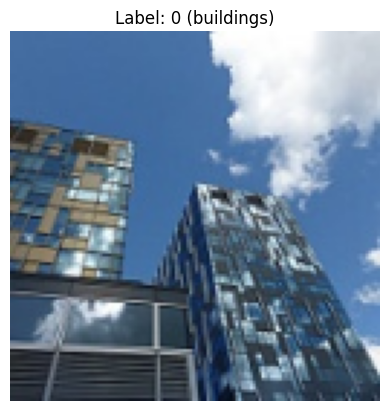

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Define the Custom Dataset Class
class IntelFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Get class names from folder names
        self.class_names = sorted(os.listdir(root_dir))
        
        for label, class_name in enumerate(self.class_names):
            class_folder = os.path.join(root_dir, class_name)
            # Ensure it's a directory
            if os.path.isdir(class_folder):
                for file_name in os.listdir(class_folder):
                    file_path = os.path.join(class_folder, file_name)
                    self.image_paths.append(file_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open image and convert to RGB
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# 2. Define Transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# 3. Create Dataset Object and DataLoader
# NOTE: In Kaggle, the path will look something like "/kaggle/input/intel-image-classification/seg_train/seg_train"
dataset_path = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train" # Adjust path as needed
folder_dataset = IntelFolderDataset(root_dir=dataset_path, transform=transform)
folder_dataloader = DataLoader(folder_dataset, batch_size=5, shuffle=True)

# 4. Check Results and Display Images
for images, labels in folder_dataloader:
    print("Image batch shape:", images.shape)
    print("Labels:", labels)
    
    # Display the first image in the batch
    image = images[0].permute(1, 2, 0) # Convert tensor to image format (H, W, C)
    plt.imshow(image)
    class_name = folder_dataset.class_names[labels[0].item()]
    plt.title(f"Label: {labels[0].item()} ({class_name})")
    plt.axis("off")
    plt.show()
    break

In [4]:
import pandas as pd

def create_dataset_csv(root_dir, output_csv):
    data = []
    class_names = sorted(os.listdir(root_dir))
    
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(root_dir, class_name)
        if os.path.isdir(class_folder):
            for file_name in os.listdir(class_folder):
                # Save relative path or just filename based on your preference
                file_path = os.path.join(class_name, file_name)
                data.append({"filename": file_path, "label": label})
                
    # Create DataFrame and save to CSV
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"CSV successfully created at {output_csv} with {len(df)} records.")

# Run the script to generate the CSV
csv_file_path = "intel_dataset.csv"
create_dataset_csv(root_dir=dataset_path, output_csv=csv_file_path)

CSV successfully created at intel_dataset.csv with 14034 records.


CSV DataLoader - Image batch shape: torch.Size([4, 3, 128, 128])
CSV DataLoader - Labels: tensor([3, 2, 3, 4])


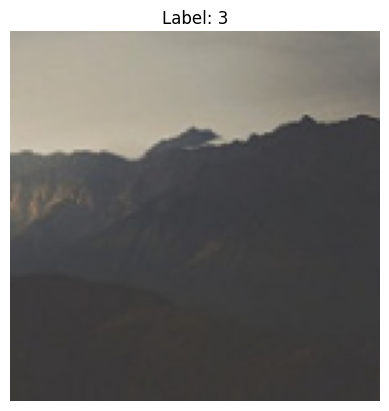

In [5]:
class IntelCSVDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Read path and label from CSV
        img_name = self.data.iloc[idx, 0]
        label = self.data.iloc[idx, 1]
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 1. Create Dataset Object and DataLoader
csv_dataset = IntelCSVDataset(csv_file=csv_file_path, root_dir=dataset_path, transform=transform)
csv_dataloader = DataLoader(csv_dataset, batch_size=4, shuffle=True)

# 2. Check Results and Display
for images, labels in csv_dataloader:
    print("CSV DataLoader - Image batch shape:", images.shape)
    print("CSV DataLoader - Labels:", labels)
    
    # Display the first image
    image = images[0].permute(1, 2, 0)
    plt.imshow(image)
    plt.title(f"Label: {labels[0].item()}")
    plt.axis("off")
    plt.show()
    break